# KPCAs

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, KernelPCA
from sklearn.datasets import make_circles
from sklearn.preprocessing import StandardScaler

## 1. Generación de datos

Utilizamos un dataset compuesto por datos distribuidos en dos círculos concéntricos, cada uno perteneciente a una de las 2 clases

In [44]:
def generate_data():
    X, y = make_circles(n_samples=500, factor=0.3, noise=0.05)
    return X, y

[0 0 0 1 1 0 1 1 1 0 1 0 1 1 1 1 0 0 0 0 1 0 1 1 0 0 0 0 0 1 0 1 0 1 0 0 0
 0 0 1 0 1 1 1 0 1 1 1 1 0 1 0 1 0 0 0 1 0 0 1 0 0 1 0 1 1 1 0 1 0 0 0 0 0
 0 0 1 0 1 1 0 0 1 0 1 1 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 0 1
 0 0 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 0 0 0 1 1 0 1 1 1 1 0 1 1 0
 1 0 0 1 1 1 0 0 0 1 0 0 1 1 0 1 1 1 0 0 0 1 1 0 0 0 1 1 1 0 0 1 1 0 1 1 0
 1 1 1 1 1 1 1 0 1 0 0 1 0 0 1 1 0 0 1 0 1 1 0 0 0 1 1 1 1 0 0 0 1 1 0 1 0
 0 0 0 1 1 0 0 1 0 0 1 0 1 1 0 1 1 1 1 0 0 1 1 0 1 0 0 0 0 1 1 1 0 0 1 1 0
 0 0 1 0 1 1 0 1 0 0 1 0 1 1 1 0 1 0 0 1 1 1 1 1 0 0 0 0 0 0 1 1 0 1 1 1 0
 1 0 0 0 1 0 0 1 0 1 1 0 0 1 1 0 1 1 0 0 1 0 1 0 0 1 1 1 1 1 0 0 0 0 1 1 1
 0 1 0 1 0 0 1 1 1 0 1 0 1 0 1 0 0 1 1 0 0 0 0 0 1 1 1 1 0 0 0 1 0 1 1 0 0
 1 0 0 1 0 1 0 0 0 0 0 1 0 0 1 0 0 0 0 0 1 0 1 1 1 0 0 0 0 1 0 1 0 0 0 0 1
 1 0 1 1 1 1 0 0 1 0 1 0 1 0 0 0 0 1 1 1 0 0 0 1 0 1 1 1 1 0 0 1 1 0 1 0 1
 1 0 0 1 0 0 1 1 0 0 1 1 1 1 0 1 1 1 0 1 1 0 0 0 0 1 0 0 1 1 1 1 0 1 1 1 0
 0 1 1 1 1 1 0 0 0 1 0 0 

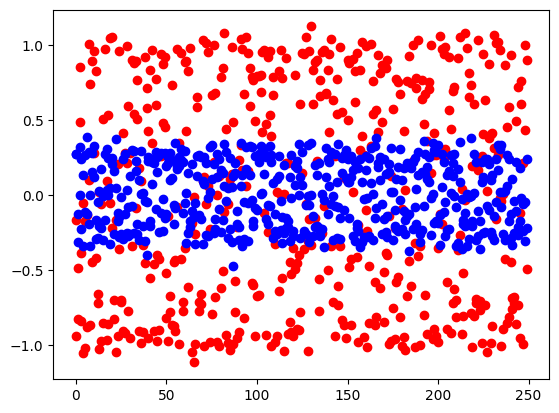

In [70]:
X, y = generate_data()
print(y)

plt.plot(X[y==0], 'ro')
plt.plot(X[y==1], 'bo')

## 2. PCA

Transformamos los datos utilizando PCA.

[[ 1.14741199e+00  1.77602850e+00]
 [-1.47456873e+00 -1.23341600e+00]
 [ 1.89210292e+00  5.37424516e-02]
 [ 1.40561241e-01 -6.10830698e-01]
 [-1.83223869e-01  6.65858411e-01]
 [-5.47584469e-02  7.90215099e-01]
 [-4.22623481e-01 -5.62674481e-01]
 [-3.54236181e-02 -6.01593667e-01]
 [ 4.38125076e-01 -2.67322320e-01]
 [ 3.93175157e-01 -1.51442187e-01]
 [ 5.13850108e-02  5.57083701e-01]
 [-1.38171167e+00 -1.32829019e+00]
 [-1.52677375e+00  1.28801009e+00]
 [-6.31569561e-01 -1.36134613e-01]
 [ 3.50664294e-01  5.75483965e-01]
 [ 5.24168981e-01 -4.36711656e-01]
 [-4.30038028e-01 -2.46661526e-01]
 [ 5.80114307e-02 -7.21199274e-01]
 [ 6.29467111e-02  5.45800590e-01]
 [-5.00817598e-01 -1.03704897e-01]
 [-1.60709198e+00 -8.77589278e-01]
 [ 6.21207545e-01  1.13135579e-01]
 [-3.61336180e-01 -1.85888420e+00]
 [-1.49519941e+00 -1.20598303e+00]
 [-1.47849035e+00 -1.10742664e+00]
 [-3.74783874e-01  3.46934331e-01]
 [-1.79418369e+00 -2.59160743e-01]
 [ 7.75515472e-01 -1.55918403e+00]
 [-8.19188395e-02  4

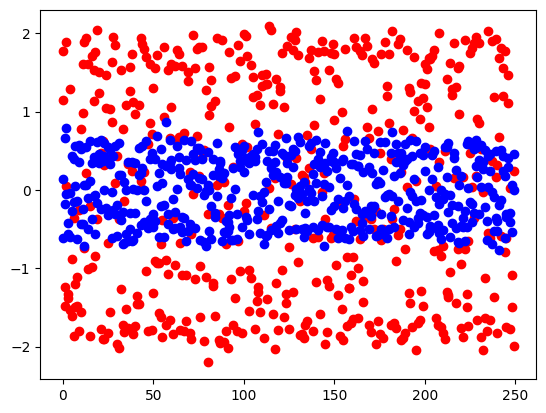

In [69]:
X_std = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_std)
print(X_pca)

plt.plot(X_pca[y==0], 'ro')
plt.plot(X_pca[y==1], 'bo')

¿Qué ocurre con la transformación?

...

## 3. KPCA con Kernel Lineal 

Compara el resultado de PCA con el de KPCA utilizando un kernel **lineal**

[[-1.14741199 -1.7760285  -0.        ]
 [ 1.47456873  1.233416    0.        ]
 [-1.89210292 -0.05374245 -0.        ]
 ...
 [-0.02473651  1.78064277 -0.        ]
 [ 1.49347361  1.08750563 -0.        ]
 [ 1.99643255 -0.23894344 -0.        ]]


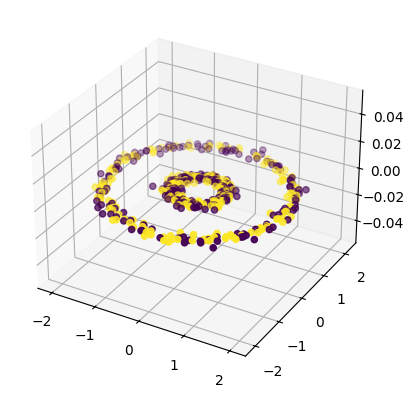

In [76]:
kpca_l = KernelPCA(n_components=3, kernel="linear", gamma=10, fit_inverse_transform=True, alpha=0.1)

X_kpca_l = kpca_l.fit_transform(X_std)
print(X_kpca_l)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(X_kpca_l[:, 0], X_kpca_l[:, 1], X_kpca_l[:, 2], c=y, cmap='viridis')

## 4. KPCA con Kernel Polinomial

Observa cómo se transforman los datos utilizando un kernel polinómico. Utiliza 3 valores distintos de **p**

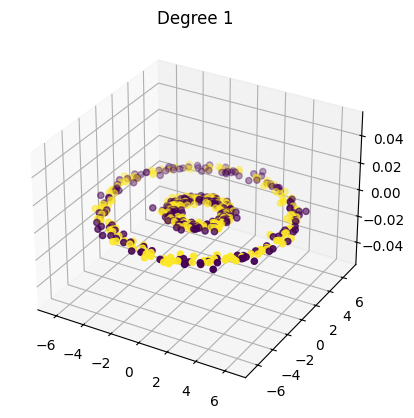

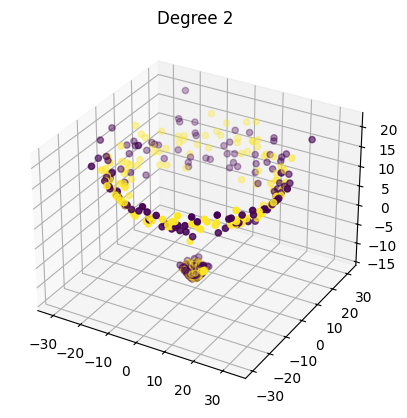

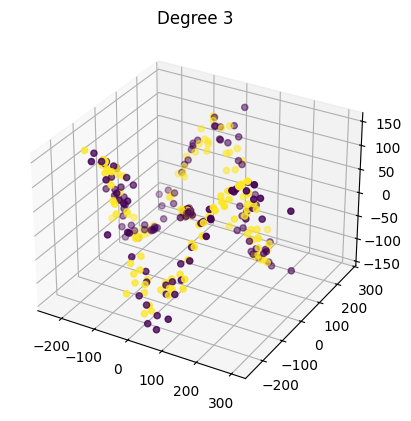

In [85]:
for i in range(1, 4):
    kpca_l = KernelPCA(n_components=3, kernel="poly", degree = i, gamma=10, alpha=0.1)
    X_kpca_l = kpca_l.fit_transform(X_std)
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    ax.scatter(X_kpca_l[:, 0], X_kpca_l[:, 1], X_kpca_l[:, 2], c=y, cmap='viridis')
    ax.set_title(f"Degree {i}")
    plt.show()


## KPCA con Kernel Gaussiano

Observa cómo se transforman los datos utilizando un kernel polinómico. Utiliza 3 valores distintos de $\gamma$

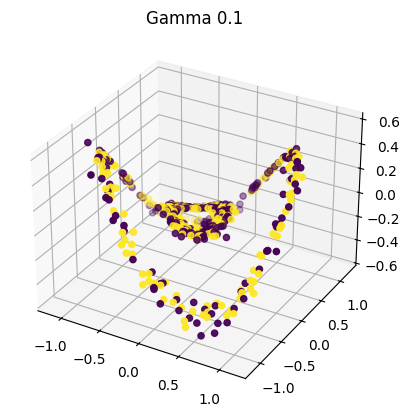

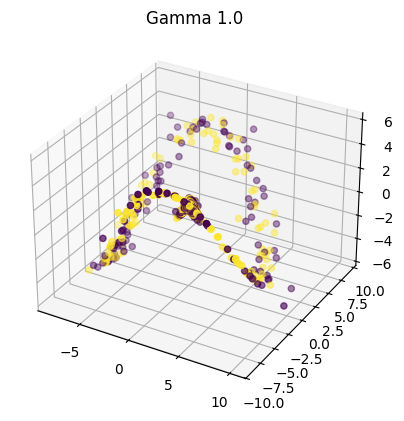

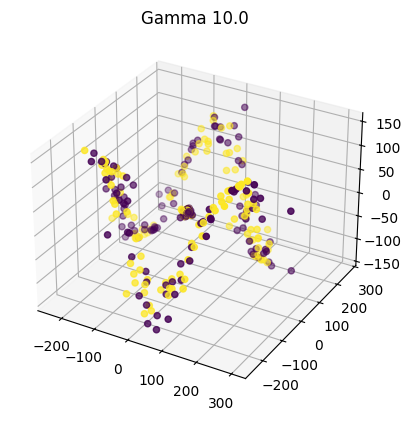

In [89]:
for i in np.array([0.1, 1, 10]):
    kpca_l = KernelPCA(n_components=3, kernel="poly", gamma = i, alpha=0.1)
    X_kpca_l = kpca_l.fit_transform(X_std)
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    ax.scatter(X_kpca_l[:, 0], X_kpca_l[:, 1], X_kpca_l[:, 2], c=y, cmap='viridis')
    ax.set_title(f"Gamma {i}")
    plt.show()